Using device: cuda
Keys in .mat file:
dict_keys(['__header__', '__version__', '__globals__', 's_train', 'u_train'])
Raw u_train shape: (1250, 200, 200)
Raw s_train shape: (1250, 200, 1)
Processed branch input shape: (1250, 200)
Processed output field shape: (1250, 200, 200)


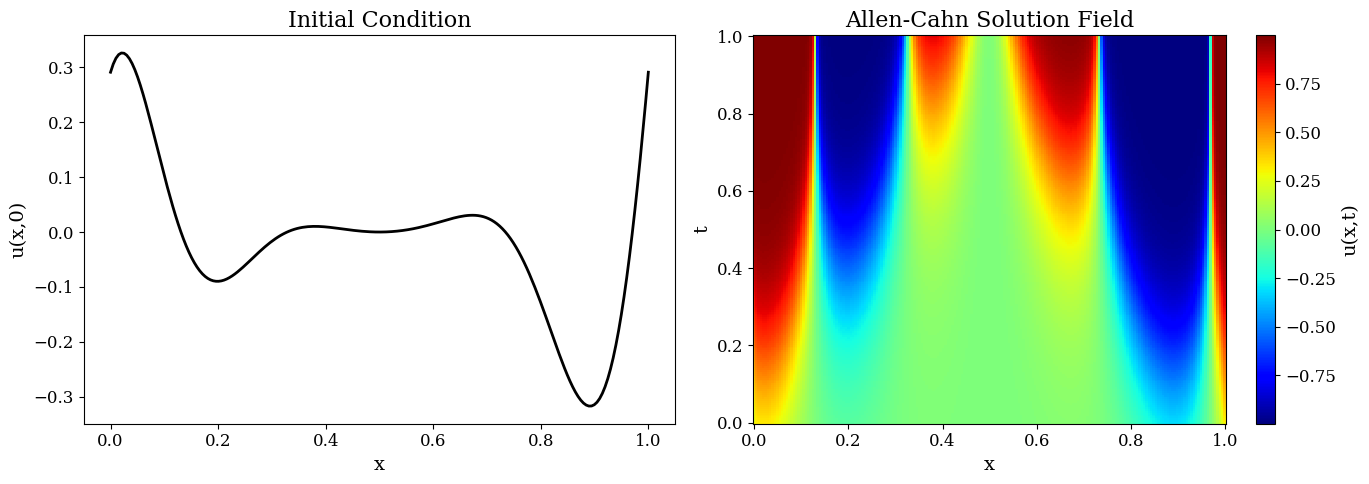

X_train_full: (1000, 200)
X_test      : (250, 200)
y_train_full: (1000, 200, 200)
y_test      : (250, 200, 200)
Training sizes used: [50, 100, 200, 400, 600, 800, 1000]

TRAINING SIZE = 50
[FEDONet-50] Epoch [1/3000] | Train Loss: 4.57107425e-01 | Test Loss: 4.28544396e-01 | LR: 9.999473e-04
[FEDONet-50] Epoch [100/3000] | Train Loss: 5.52336574e-02 | Test Loss: 6.67316872e-02 | LR: 9.947458e-04
[FEDONet-50] Epoch [200/3000] | Train Loss: 2.47620661e-02 | Test Loss: 3.52159501e-02 | LR: 9.895193e-04
[FEDONet-50] Epoch [300/3000] | Train Loss: 1.54942106e-02 | Test Loss: 2.71656535e-02 | LR: 9.843202e-04
[FEDONet-50] Epoch [400/3000] | Train Loss: 1.03345783e-02 | Test Loss: 2.44512579e-02 | LR: 9.791484e-04
[FEDONet-50] Epoch [500/3000] | Train Loss: 7.32992776e-03 | Test Loss: 2.42754063e-02 | LR: 9.740037e-04
[FEDONet-50] Epoch [600/3000] | Train Loss: 5.79402037e-03 | Test Loss: 2.37480669e-02 | LR: 9.688862e-04
[FEDONet-50] Epoch [700/3000] | Train Loss: 4.75236820e-03 | Test Loss:

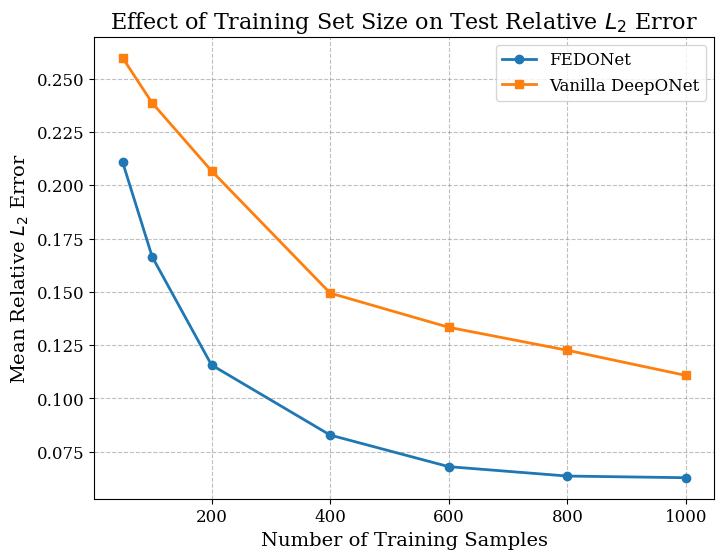

In [2]:
# ============================================================
# ALLEN-CAHN: EFFECT OF TRAINING DATA SIZE ON TEST RELATIVE L2
# FEDONet vs Vanilla DeepONet
# End-to-end code
# ============================================================

import os
import random
import copy
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import matplotlib as mpl

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
from skimage.metrics import structural_similarity as ssim
from tabulate import tabulate

# ============================================================
# 1. REPRODUCIBILITY
# ============================================================
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================================
# 2. HYPERPARAMETERS
# ============================================================
n_train_total = 1250
test_size = 0.2

grid_size = 200
latent_dim = 100
fourier_mapping_size = 256

batch_size = 128
learning_rate = 1e-3

# ---- IMPORTANT ----
# 5000 epochs for each training size is very expensive.
# Start smaller, then increase if needed.
num_epochs_sweep = 3000

# Training sizes to test
training_sizes = [50, 100, 200, 400, 600, 800, 1000]

# ============================================================
# 3. PLOT SETTINGS
# ============================================================
def set_plot_params():
    mpl.rcParams['figure.figsize'] = (8, 6)
    mpl.rcParams['figure.dpi'] = 100
    mpl.rcParams['savefig.dpi'] = 300

    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.size'] = 12
    mpl.rcParams['axes.titlesize'] = 16
    mpl.rcParams['axes.labelsize'] = 14
    mpl.rcParams['xtick.labelsize'] = 12
    mpl.rcParams['ytick.labelsize'] = 12
    mpl.rcParams['legend.fontsize'] = 12

    mpl.rcParams['lines.linewidth'] = 2
    mpl.rcParams['lines.markersize'] = 6

    mpl.rcParams['contour.negative_linestyle'] = 'solid'
    mpl.rcParams['grid.linestyle'] = '--'
    mpl.rcParams['grid.color'] = 'gray'
    mpl.rcParams['grid.alpha'] = 0.5

    mpl.rcParams['image.cmap'] = 'plasma'

set_plot_params()

# ============================================================
# 4. METRICS
# ============================================================
def relative_l2_error_sample(y_true, y_pred):
    return np.linalg.norm(y_true - y_pred) / (np.linalg.norm(y_true) + 1e-12)

def relative_l2_error_batch(y_true, y_pred):
    errs = []
    for i in range(y_true.shape[0]):
        errs.append(relative_l2_error_sample(y_true[i], y_pred[i]))
    return float(np.mean(errs))

def compute_mse_batch(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))

def compute_mae_batch(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def compute_ssim_batch(y_true, y_pred):
    vals = []
    for i in range(y_true.shape[0]):
        dr = y_true[i].max() - y_true[i].min()
        if dr < 1e-12:
            dr = 1.0
        vals.append(ssim(y_true[i], y_pred[i], data_range=dr))
    return float(np.mean(vals))

# ============================================================
# 5. LOAD DATA
# ============================================================
data = scipy.io.loadmat("Allen_Cahn_4_terms_more_resolution.mat")

print("Keys in .mat file:")
print(data.keys())

u_data = data["u_train"][:n_train_total]   # expected full solution, shape (N, 200, 200)
s_data = data["s_train"][:n_train_total]   # expected IC or related input

print("Raw u_train shape:", u_data.shape)
print("Raw s_train shape:", s_data.shape)

# ------------------------------------------------------------
# Robust extraction of branch input (initial condition)
# ------------------------------------------------------------
if s_data.ndim == 2:
    X_input = s_data

elif s_data.ndim == 3:
    if s_data.shape[1] == grid_size and s_data.shape[2] == 1:
        X_input = s_data[:, :, 0]
    elif s_data.shape[1] == 1 and s_data.shape[2] == grid_size:
        X_input = s_data[:, 0, :]
    elif s_data.shape[1] == grid_size and s_data.shape[2] == grid_size:
        X_input = s_data[:, :, 0]
    else:
        raise ValueError(f"Unsupported s_train shape: {s_data.shape}")
else:
    raise ValueError(f"Unsupported s_train ndim: {s_data.ndim}")

Y_field = u_data

if X_input.shape[1] != grid_size:
    raise ValueError(f"Branch input must have length {grid_size}, got {X_input.shape}")

if Y_field.shape[1:] != (grid_size, grid_size):
    raise ValueError(f"Output field must have shape (N, {grid_size}, {grid_size}), got {Y_field.shape}")

print("Processed branch input shape:", X_input.shape)
print("Processed output field shape:", Y_field.shape)

# ============================================================
# 6. VISUALIZE ONE SAMPLE
# ============================================================
sample_idx = random.randint(0, X_input.shape[0] - 1)

x = np.linspace(0, 1, grid_size)
t = np.linspace(0, 1, grid_size)
XX, TT = np.meshgrid(x, t)

fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(x, X_input[sample_idx], color='k')
ax1.set_xlabel('x')
ax1.set_ylabel('u(x,0)')
ax1.set_title('Initial Condition')

ax2 = fig.add_subplot(1, 2, 2)
pcm = ax2.pcolor(XX, TT, Y_field[sample_idx].T, cmap='jet')
ax2.set_xlabel('x')
ax2.set_ylabel('t')
ax2.set_title('Allen-Cahn Solution Field')
fig.colorbar(pcm, ax=ax2, label='u(x,t)')

plt.tight_layout()
plt.show()

# ============================================================
# 7. TRAIN / TEST SPLIT
# ============================================================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_input, Y_field, test_size=test_size, random_state=42
)

print("X_train_full:", X_train_full.shape)
print("X_test      :", X_test.shape)
print("y_train_full:", y_train_full.shape)
print("y_test      :", y_test.shape)

max_possible_train = X_train_full.shape[0]
training_sizes = [n for n in training_sizes if n <= max_possible_train]
print("Training sizes used:", training_sizes)

# ============================================================
# 8. DATASET
# ============================================================
class AllenCahnDataset(Dataset):
    def __init__(self, initial_condition, full_solution, grid_size=200):
        self.initial_condition = torch.tensor(initial_condition, dtype=torch.float32)
        self.full_solution = torch.tensor(full_solution, dtype=torch.float32)

        grid = np.linspace(0, 1, grid_size)
        Xg, Tg = np.meshgrid(grid, grid)
        coords = np.stack([Xg, Tg], axis=-1)      # (200, 200, 2)
        self.coords = torch.tensor(coords, dtype=torch.float32)

    def __len__(self):
        return self.initial_condition.shape[0]

    def __getitem__(self, idx):
        return self.initial_condition[idx], self.full_solution[idx]

train_dataset_full = AllenCahnDataset(X_train_full, y_train_full, grid_size=grid_size)
test_dataset = AllenCahnDataset(X_test, y_test, grid_size=grid_size)

test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
coords = train_dataset_full.coords.to(device)

# ============================================================
# 9. MODELS
# ============================================================
class FourierEmbedding(nn.Module):
    def __init__(self, input_dim, mapping_size=256, scale=10.0):
        super().__init__()
        B = torch.randn(input_dim, mapping_size) * scale
        self.register_buffer("B", B)

    def forward(self, x):
        x_proj = 2.0 * np.pi * x @ self.B
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class TrunkNetFEDO(nn.Module):
    def __init__(self, input_dim=2, mapping_size=256, latent_dim=100):
        super().__init__()
        self.fourier_embed = FourierEmbedding(input_dim, mapping_size=mapping_size)
        self.fc = nn.Sequential(
            nn.Linear(2 * mapping_size, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim),
        )

    def forward(self, x):
        x = self.fourier_embed(x)
        return self.fc(x)

class BranchNetFEDO(nn.Module):
    def __init__(self, input_dim=200, latent_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, latent_dim),
        )

    def forward(self, x):
        return self.net(x)

class FEDONet(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.branch_net = BranchNetFEDO(input_dim=grid_size, latent_dim=latent_dim)
        self.trunk_net  = TrunkNetFEDO(input_dim=2, mapping_size=fourier_mapping_size, latent_dim=latent_dim)

    def forward(self, initial_condition, coords):
        batch_size = initial_condition.size(0)
        H = coords.size(0)
        W = coords.size(1)

        coords_flat = coords.view(-1, 2)                 # (H*W, 2)
        trunk_out = self.trunk_net(coords_flat)          # (H*W, latent_dim)
        branch_out = self.branch_net(initial_condition)  # (B, latent_dim)

        outputs = torch.matmul(branch_out, trunk_out.T)  # (B, H*W)
        outputs = outputs.view(batch_size, H, W)
        return outputs

class TrunkNetVanilla(nn.Module):
    def __init__(self, input_dim=2, latent_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, latent_dim),
        )

    def forward(self, x):
        return self.net(x)

class BranchNetVanilla(nn.Module):
    def __init__(self, input_dim=200, latent_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, latent_dim),
        )

    def forward(self, x):
        return self.net(x)

class DeepONetVanilla(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.branch_net = BranchNetVanilla(input_dim=grid_size, latent_dim=latent_dim)
        self.trunk_net  = TrunkNetVanilla(input_dim=2, latent_dim=latent_dim)

    def forward(self, initial_condition, coords):
        batch_size = initial_condition.size(0)
        H = coords.size(0)
        W = coords.size(1)

        coords_flat = coords.view(-1, 2)                 # (H*W, 2)
        trunk_out = self.trunk_net(coords_flat)          # (H*W, latent_dim)
        branch_out = self.branch_net(initial_condition)  # (B, latent_dim)

        outputs = torch.matmul(branch_out, trunk_out.T)  # (B, H*W)
        outputs = outputs.view(batch_size, H, W)
        return outputs

# ============================================================
# 10. TRAIN / EVAL FUNCTIONS
# ============================================================
def train_one_epoch(model, loader, optimizer, criterion, device, coords):
    model.train()
    running_loss = 0.0

    for ic, sol in loader:
        ic = ic.to(device)
        sol = sol.to(device)

        optimizer.zero_grad()
        pred = model(ic, coords)
        loss = criterion(pred, sol)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * ic.size(0)

    return running_loss / len(loader.dataset)

def evaluate_loss(model, loader, criterion, device, coords):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for ic, sol in loader:
            ic = ic.to(device)
            sol = sol.to(device)

            pred = model(ic, coords)
            loss = criterion(pred, sol)
            running_loss += loss.item() * ic.size(0)

    return running_loss / len(loader.dataset)

def predict_full_dataset(model, X_input_np, y_true_np, coords, batch_size=128, device="cpu"):
    model.eval()

    X_tensor = torch.tensor(X_input_np, dtype=torch.float32)
    y_tensor = torch.tensor(y_true_np, dtype=torch.float32)

    loader = DataLoader(
        torch.utils.data.TensorDataset(X_tensor, y_tensor),
        batch_size=batch_size,
        shuffle=False
    )

    preds = []
    trues = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            out = model(xb, coords)

            preds.append(out.cpu().numpy())
            trues.append(yb.cpu().numpy())

    y_pred = np.concatenate(preds, axis=0)
    y_true = np.concatenate(trues, axis=0)
    return y_true, y_pred

def evaluate_metrics(model, X_input_np, y_true_np, coords, batch_size=128, device="cpu"):
    y_true, y_pred = predict_full_dataset(model, X_input_np, y_true_np, coords, batch_size, device)

    metrics = {
        "rel_l2": relative_l2_error_batch(y_true, y_pred),
        "mse": compute_mse_batch(y_true, y_pred),
        "mae": compute_mae_batch(y_true, y_pred),
        "ssim": compute_ssim_batch(y_true, y_pred),
    }
    return metrics, y_true, y_pred

# ============================================================
# 11. MODEL TRAINER
# ============================================================
def train_model(
    model,
    train_loader,
    test_loader,
    coords,
    num_epochs=1500,
    lr=1e-3,
    device="cpu",
    model_name="Model"
):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer, lr_lambda=lambda epoch: 0.9 ** (epoch / 2000)
    )

    train_losses = []
    test_losses = []

    best_state = copy.deepcopy(model.state_dict())
    best_test_loss = float("inf")

    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, coords)
        test_loss = evaluate_loss(model, test_loader, criterion, device, coords)

        train_losses.append(train_loss)
        test_losses.append(test_loss)

        if test_loss < best_test_loss:
            best_test_loss = test_loss
            best_state = copy.deepcopy(model.state_dict())

        scheduler.step()

        if (epoch + 1) % 100 == 0 or epoch == 0 or epoch == num_epochs - 1:
            print(f"[{model_name}] Epoch [{epoch+1}/{num_epochs}] | "
                  f"Train Loss: {train_loss:.8e} | "
                  f"Test Loss: {test_loss:.8e} | "
                  f"LR: {optimizer.param_groups[0]['lr']:.6e}")

    model.load_state_dict(best_state)
    return model, train_losses, test_losses, best_test_loss

# ============================================================
# 12. SWEEP OVER TRAINING SIZES
# ============================================================
results_table = []

fedo_rel_l2_sizes = []
vanilla_rel_l2_sizes = []

fedo_mse_sizes = []
vanilla_mse_sizes = []

fedo_ssim_sizes = []
vanilla_ssim_sizes = []

# fixed shuffled indices so comparison is fair
all_train_indices = np.arange(len(train_dataset_full))
rng = np.random.default_rng(seed)
rng.shuffle(all_train_indices)

for n_train in training_sizes:
    print("\n" + "=" * 80)
    print(f"TRAINING SIZE = {n_train}")
    print("=" * 80)

    subset_indices = all_train_indices[:n_train]
    train_subset = Subset(train_dataset_full, subset_indices)
    train_loader_subset = DataLoader(train_subset, batch_size=batch_size, shuffle=True)

    # ---------------- FEDONet ----------------
    fedo_model = FEDONet(latent_dim=latent_dim).to(device)
    fedo_model, fedo_train_losses, fedo_test_losses, fedo_best_loss = train_model(
        fedo_model,
        train_loader_subset,
        test_loader,
        coords,
        num_epochs=num_epochs_sweep,
        lr=learning_rate,
        device=device,
        model_name=f"FEDONet-{n_train}"
    )

    fedo_metrics, _, _ = evaluate_metrics(
        fedo_model, X_test, y_test, coords, batch_size=batch_size, device=device
    )

    # ---------------- Vanilla DeepONet ----------------
    vanilla_model = DeepONetVanilla(latent_dim=latent_dim).to(device)
    vanilla_model, vanilla_train_losses, vanilla_test_losses, vanilla_best_loss = train_model(
        vanilla_model,
        train_loader_subset,
        test_loader,
        coords,
        num_epochs=num_epochs_sweep,
        lr=learning_rate,
        device=device,
        model_name=f"Vanilla-{n_train}"
    )

    vanilla_metrics, _, _ = evaluate_metrics(
        vanilla_model, X_test, y_test, coords, batch_size=batch_size, device=device
    )

    fedo_rel_l2_sizes.append(fedo_metrics["rel_l2"])
    vanilla_rel_l2_sizes.append(vanilla_metrics["rel_l2"])

    fedo_mse_sizes.append(fedo_metrics["mse"])
    vanilla_mse_sizes.append(vanilla_metrics["mse"])

    fedo_ssim_sizes.append(fedo_metrics["ssim"])
    vanilla_ssim_sizes.append(vanilla_metrics["ssim"])

    results_table.append([
        n_train,
        f"{fedo_metrics['rel_l2']:.6f}",
        f"{vanilla_metrics['rel_l2']:.6f}",
        f"{fedo_metrics['mse']:.6e}",
        f"{vanilla_metrics['mse']:.6e}",
        f"{fedo_metrics['ssim']:.6f}",
        f"{vanilla_metrics['ssim']:.6f}",
    ])

    print(f"\nResults for n_train = {n_train}")
    print(f"FEDONet         -> RelL2: {fedo_metrics['rel_l2']:.6f}, "
          f"MSE: {fedo_metrics['mse']:.6e}, SSIM: {fedo_metrics['ssim']:.6f}")
    print(f"Vanilla DeepONet-> RelL2: {vanilla_metrics['rel_l2']:.6f}, "
          f"MSE: {vanilla_metrics['mse']:.6e}, SSIM: {vanilla_metrics['ssim']:.6f}")

# ============================================================
# 13. RESULTS TABLE
# ============================================================
headers = [
    "Train Size",
    "FEDONet RelL2",
    "Vanilla RelL2",
    "FEDONet MSE",
    "Vanilla MSE",
    "FEDONet SSIM",
    "Vanilla SSIM",
]

print("\n=== EFFECT OF TRAINING SIZE ON TEST PERFORMANCE ===")
print(tabulate(results_table, headers=headers, tablefmt="grid"))

# ============================================================
# 14. PLOT: RELATIVE L2 ERROR VS TRAINING SIZE
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(training_sizes, fedo_rel_l2_sizes, marker='o', label='FEDONet')
plt.plot(training_sizes, vanilla_rel_l2_sizes, marker='s', label='Vanilla DeepONet')
plt.xlabel('Number of Training Samples')
plt.ylabel('Mean Relative $L_2$ Error')
plt.title('Effect of Training Set Size on Test Relative $L_2$ Error')
plt.grid(True)
plt.legend()
plt.show()


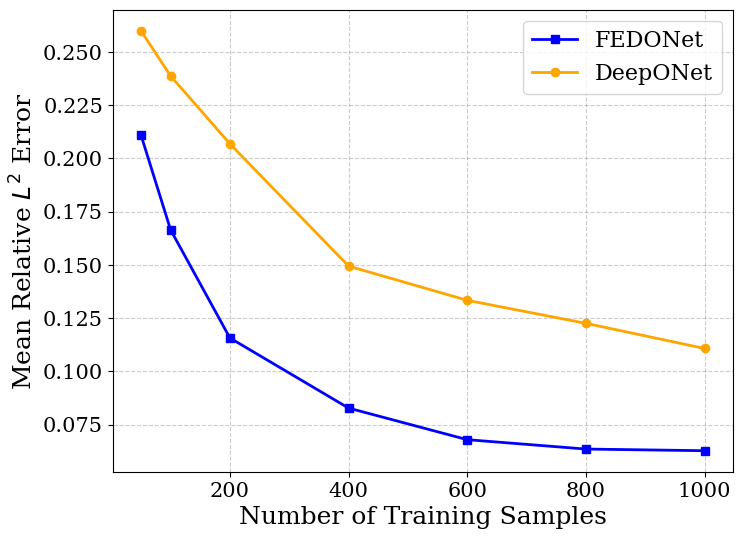

In [3]:
import matplotlib as mpl


def set_plot_params():
    mpl.rcParams['figure.figsize'] = (8, 6)
    mpl.rcParams['figure.dpi'] = 100
    mpl.rcParams['savefig.dpi'] = 300
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.size'] = 15
    mpl.rcParams['axes.titlesize'] = 16
    mpl.rcParams['axes.labelsize'] = 14
    mpl.rcParams['xtick.labelsize'] = 12
    mpl.rcParams['ytick.labelsize'] = 12
    mpl.rcParams['legend.fontsize'] = 12
    mpl.rcParams['grid.linestyle'] = '--'
    mpl.rcParams['grid.color'] = 'gray'
    mpl.rcParams['grid.alpha'] = 0.5
    mpl.rcParams['image.cmap'] = 'viridis'

set_plot_params()

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 21,
    'axes.labelsize': 18,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 16
})

plt.figure(figsize=(8, 6))
plt.plot(training_sizes, fedo_rel_l2_sizes, marker='s', color='blue', linewidth=2, label='FEDONet')
plt.plot(training_sizes, vanilla_rel_l2_sizes, marker='o', color='orange', linewidth=2, label='DeepONet')
# plt.yscale('log')
plt.xlabel('Number of Training Samples')
plt.ylabel('Mean Relative $L^2$ Error')
# plt.title('Effect of Training Set Size on Test Relative $L_2$ Error')
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend()
plt.show()

